# Sanpchat clone for Photo Filters

In [1]:
!pip install --user opencv-contrib-python==4.10.0.84 numpy matplotlib
  

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)

OpenCV version: 4.10.0
NumPy version : 2.2.6


In [3]:
# ---- Helper functions (we will learn how to write functions later; for now just run this cell and use them) ----

def show(img, title=""):
    """Show ONE image. Works for both grayscale and colour (BGR) images."""
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 2:                       # grayscale -> only (height, width)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:                                         # colour -> convert BGR to RGB for matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_many(images, titles, cols=3):
    """Show several images side by side. images and titles are two lists of the same length."""
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 3.3 * rows))
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Loaded your own photo: face.jpg (2592, 1728, 3)


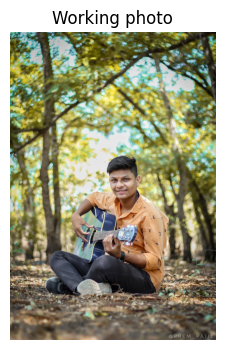

In [4]:
USING_REAL_PHOTO = os.path.exists("J:/prashant iphone/KYTP1030.JPG")

if USING_REAL_PHOTO:
    photo = cv2.imread("J:/prashant iphone/KYTP1030.JPG")
    print("Loaded your own photo: face.jpg", photo.shape)
else:
    photo = np.full((480, 480, 3), 245, np.uint8)
    cv2.ellipse(photo, (240, 250), (130, 165), 0, 0, 360, (200, 220, 255), -1)   # face
    cv2.ellipse(photo, (240, 420), (90, 60), 0, 0, 180, (200, 220, 255), -1)     # neck/shoulders hint
    cv2.circle(photo, (190, 215), 16, (30, 30, 30), -1)                          # left eye
    cv2.circle(photo, (290, 215), 16, (30, 30, 30), -1)                         # right eye
    cv2.ellipse(photo, (240, 260), (12, 22), 0, 0, 360, (150, 170, 210), -1)     # nose
    cv2.ellipse(photo, (240, 320), (42, 18), 0, 0, 180, (60, 30, 80), 3)         # smile
    cv2.ellipse(photo, (240, 60), (140, 90), 0, 180, 360, (40, 60, 90), -1)      # hair
    print("face.jpg not found -> using a drawn cartoon face as a stand-in")

show(photo, "Working photo")  # if USING_REAL_PHOTO else "Working photo (cartoon stand-in)")

Detector found a face: True -> (np.int32(789), np.int32(1139), np.int32(270), np.int32(270))
Face box used from here on: (np.int32(789), np.int32(1139), np.int32(270), np.int32(270))


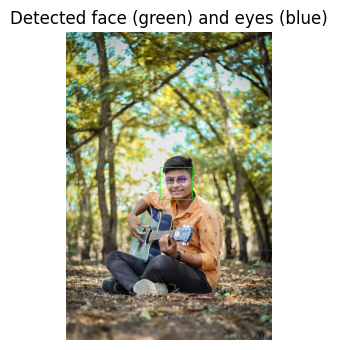

In [5]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def detect_face_box(img):
    """Return the biggest detected face as (x, y, w, h), or None if nothing was found."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return None
    # keep the LARGEST box (closest / main face) -> area = w * h
    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    return tuple(faces[0])

def detect_eyes(img, face_box):
    """Look for eyes ONLY inside the face box (faster + fewer false positives)."""
    x, y, w, h = face_box
    roi_gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=8, minSize=(15, 15))
    # convert eye coords from ROI-local back to full-image coords
    return [(x + ex, y + ey, ew, eh) for (ex, ey, ew, eh) in eyes]

detected = detect_face_box(photo)
print("Detector found a face:", detected is not None, "->", detected)

# FALLBACK: only used for the cartoon stand-in, so every filter below has something to draw on
FACE_BOX = detected if detected is not None else (110, 85, 260, 330)
print("Face box used from here on:", FACE_BOX)

preview = photo.copy()
x, y, w, h = FACE_BOX
cv2.rectangle(preview, (x, y), (x + w, y + h), (0, 255, 0), 3)
for (ex, ey, ew, eh) in detect_eyes(photo, FACE_BOX):
    cv2.rectangle(preview, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
show(preview, "Detected face (green) and eyes (blue)")

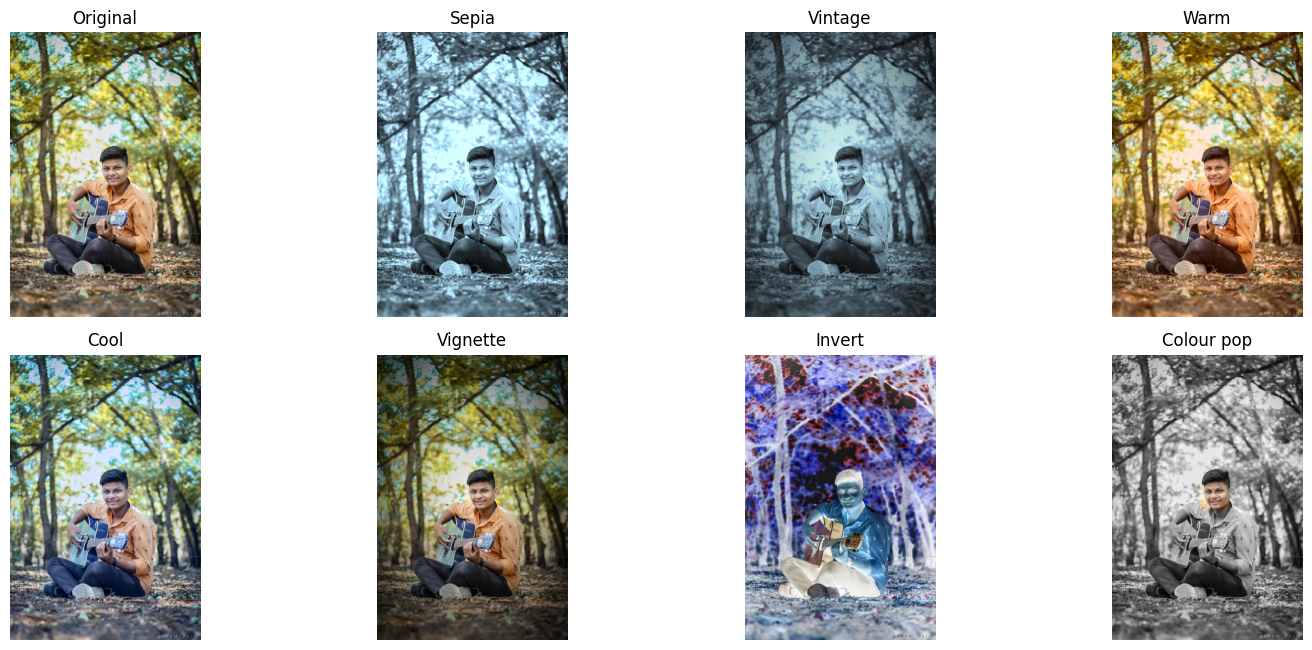

In [6]:
def apply_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)          # back to 3 channels so it still "fits" with colour filters


def apply_invert(img):
    return cv2.bitwise_not(img)


def apply_sepia(img):
    # Classic sepia matrix (applied to RGB order, so we convert first)
    kernel = np.array([[0.272, 0.534, 0.131],
                        [0.349, 0.686, 0.168],
                        [0.393, 0.769, 0.189]])
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    sepia = rgb @ kernel.T
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)
    return cv2.cvtColor(sepia, cv2.COLOR_RGB2BGR)


def apply_warm(img):
    b, g, r = cv2.split(img)
    r = cv2.add(r, 25)
    b = cv2.subtract(b, 15)
    return cv2.merge([b, g, r])


def apply_cool(img):
    b, g, r = cv2.split(img)
    b = cv2.add(b, 25)
    r = cv2.subtract(r, 15)
    return cv2.merge([b, g, r])


def apply_vignette(img, strength=2.2):
    h, w = img.shape[:2]
    kx = cv2.getGaussianKernel(w, w / strength)
    ky = cv2.getGaussianKernel(h, h / strength)
    mask = ky @ kx.T
    mask = mask / mask.max()                                # 0..1, bright centre
    out = img.astype(np.float32)
    for c in range(3):
        out[:, :, c] *= mask
    return np.clip(out, 0, 255).astype(np.uint8)


def apply_vintage(img):
    out = apply_sepia(img)
    out = apply_vignette(out, strength=2.0)
    out = cv2.convertScaleAbs(out, alpha=0.9, beta=10)       # slightly faded / lifted blacks
    noise = np.random.default_rng(0).normal(0, 8, out.shape).astype(np.int16)
    out = np.clip(out.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return out


def apply_color_pop(img, face_box):
    """Grayscale everywhere EXCEPT inside the face box, which stays in colour."""
    gray_3ch = apply_grayscale(img)
    out = gray_3ch.copy()
    x, y, w, h = face_box
    out[y:y + h, x:x + w] = img[y:y + h, x:x + w]
    return out


gallery = [photo, apply_sepia(photo), apply_vintage(photo), apply_warm(photo), apply_cool(photo),
          apply_vignette(photo), apply_invert(photo), apply_color_pop(photo, FACE_BOX)]
titles = ["Original", "Sepia", "Vintage", "Warm", "Cool", "Vignette", "Invert", "Colour pop"]
show_many(gallery, titles, cols=4)

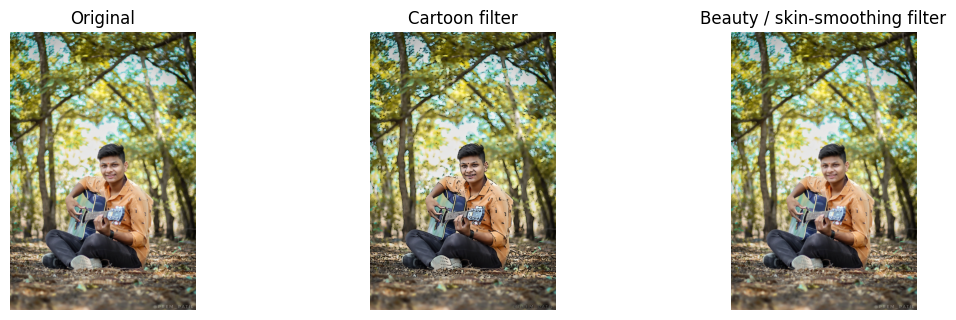

In [7]:
def apply_cartoon(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(gray, 5)
    edges = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 9)
    color = cv2.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
    cartoon = cv2.bitwise_and(color, color, mask=edges)
    return cartoon


def apply_beauty(img, face_box, strength=60):
    """Smooth skin INSIDE the face box only, blended so the edge is not visible."""
    x, y, w, h = face_box
    out = img.copy()
    smoothed = cv2.bilateralFilter(img, d=15, sigmaColor=strength, sigmaSpace=strength)

    # a soft (feathered) oval mask so the smoothing fades out at the border, not a hard cut
    mask = np.zeros(img.shape[:2], np.uint8)
    cv2.ellipse(mask, (x + w // 2, y + h // 2), (w // 2, h // 2), 0, 0, 360, 255, -1)
    mask = cv2.GaussianBlur(mask, (31, 31), 0).astype(np.float32) / 255.0

    for c in range(3):
        out[:, :, c] = (smoothed[:, :, c] * mask + img[:, :, c] * (1 - mask)).astype(np.uint8)
    return out


show_many([photo, apply_cartoon(photo), apply_beauty(photo, FACE_BOX)],
          ["Original", "Cartoon filter", "Beauty / skin-smoothing filter"], cols=3)

In [8]:
def overlay_image_alpha(background, overlay_rgba, x, y):
    """Paste overlay_rgba (H x W x 4) onto background (H x W x 3) with top-left corner at (x, y)."""
    bg_h, bg_w = background.shape[:2]
    ov_h, ov_w = overlay_rgba.shape[:2]

    # clip the overlay so it never goes outside the background
    x1, y1 = max(x, 0), max(y, 0)
    x2, y2 = min(x + ov_w, bg_w), min(y + ov_h, bg_h)
    if x1 >= x2 or y1 >= y2:
        return background                                    # completely off-screen -> nothing to draw

    ov_x1, ov_y1 = x1 - x, y1 - y
    ov_x2, ov_y2 = ov_x1 + (x2 - x1), ov_y1 + (y2 - y1)

    overlay_crop = overlay_rgba[ov_y1:ov_y2, ov_x1:ov_x2]
    alpha = overlay_crop[:, :, 3:4].astype(np.float32) / 255.0     # shape (h, w, 1) -> broadcasts over 3 channels
    overlay_rgb = overlay_crop[:, :, :3].astype(np.float32)

    out = background.copy()
    region = out[y1:y2, x1:x2].astype(np.float32)
    out[y1:y2, x1:x2] = (overlay_rgb * alpha + region * (1 - alpha)).astype(np.uint8)
    return out

C:\Users\jayes\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


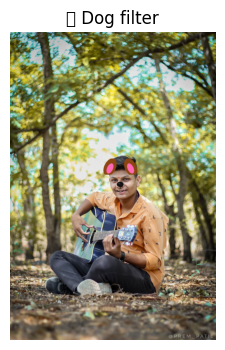

In [9]:
def make_dog_ears(w=260, h=180):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    brown, inner = (19, 69, 139), (100, 149, 237)             # BGR: saddle-brown, light peach-blue mix looks pink-ish

    for cx, angle in [(55, 25), (w - 55, -25)]:
        cv2.ellipse(canvas, (cx, 85), (48, 78), angle, 0, 360, brown, -1)
        cv2.ellipse(mask,   (cx, 85), (48, 78), angle, 0, 360, 255, -1)
        cv2.ellipse(canvas, (cx, 95), (24, 45), angle, 0, 360, (180, 105, 255), -1)   # inner pink ear

    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def make_dog_nose(w=90, h=110):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    cv2.ellipse(canvas, (w // 2, 30), (28, 22), 0, 0, 360, (20, 20, 20), -1)          # black nose
    cv2.ellipse(mask,   (w // 2, 30), (28, 22), 0, 0, 360, 255, -1)
    cv2.circle(canvas, (w // 2 - 9, 24), 4, (90, 90, 90), -1)                          # shine
    cv2.line(canvas, (w // 2, 48), (w // 2, 65), (20, 20, 20), 4)                      # line to mouth
    cv2.line(mask,   (w // 2, 48), (w // 2, 65), 255, 4)
    cv2.ellipse(canvas, (w // 2, 78), (26, 16), 0, 0, 180, (20, 20, 20), 4)             # smile
    cv2.ellipse(mask,   (w // 2, 78), (26, 16), 0, 0, 180, 255, 4)
    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def apply_dog_filter(img, face_box):
    x, y, w, h = face_box
    out = img.copy()

    ears = make_dog_ears(int(w * 1.05), int(h * 0.55))
    ears = cv2.resize(ears, (int(w * 1.05), int(h * 0.55)))
    out = overlay_image_alpha(out, ears, x + w // 2 - ears.shape[1] // 2, y - int(h * 0.32))

    nose = make_dog_nose(int(w * 0.30), int(h * 0.36))
    out = overlay_image_alpha(out, nose, x + w // 2 - nose.shape[1] // 2, y + int(h * 0.42))
    return out


show(apply_dog_filter(photo, FACE_BOX), "🐶 Dog filter")

C:\Users\jayes\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


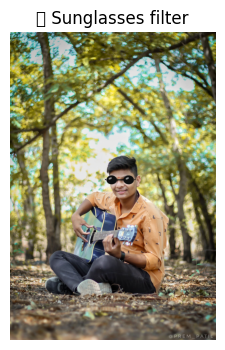

In [10]:
def make_sunglasses(w=260, h=90):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    lens_w, lens_h = int(w * 0.34), int(h * 0.85)
    cy = h // 2

    for cx in [int(w * 0.22), int(w * 0.78)]:
        cv2.ellipse(canvas, (cx, cy), (lens_w // 2, lens_h // 2), 0, 0, 360, (15, 15, 15), -1)
        cv2.ellipse(mask,   (cx, cy), (lens_w // 2, lens_h // 2), 0, 0, 360, 255, -1)
        cv2.ellipse(canvas, (cx - 12, cy - 12), (14, 7), -25, 0, 360, (150, 150, 150), -1)  # highlight

    cv2.rectangle(canvas, (int(w * 0.38), cy - 4), (int(w * 0.62), cy + 4), (15, 15, 15), -1)  # bridge
    cv2.rectangle(mask,   (int(w * 0.38), cy - 4), (int(w * 0.62), cy + 4), 255, -1)
    for cx in [8, w - 8]:                                                                       # little arms
        cv2.line(canvas, (cx, cy), (0 if cx < w // 2 else w, cy - 6), (15, 15, 15), 5)
        cv2.line(mask,   (cx, cy), (0 if cx < w // 2 else w, cy - 6), 255, 5)

    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def apply_sunglasses_filter(img, face_box):
    x, y, w, h = face_box
    eyes = detect_eyes(img, face_box)

    glasses_w = int(w * 0.95)
    glasses = make_sunglasses(glasses_w, int(glasses_w * 90 / 260))

    if len(eyes) >= 2:                                          # use the REAL eye positions
        eyes_sorted = sorted(eyes, key=lambda e: e[0])
        (lx, ly, lw, lh) = eyes_sorted[0]
        (rx, ry, rw, rh) = eyes_sorted[-1]
        centre_y = (ly + lh // 2 + ry + rh // 2) // 2
        place_x = x + w // 2 - glasses.shape[1] // 2
        place_y = centre_y - glasses.shape[0] // 2
    else:                                                        # fall back to a fixed proportion of the face box
        place_x = x + w // 2 - glasses.shape[1] // 2
        place_y = y + int(h * 0.27)

    return overlay_image_alpha(img.copy(), glasses, place_x, place_y)


show(apply_sunglasses_filter(photo, FACE_BOX), "🕶️ Sunglasses filter")

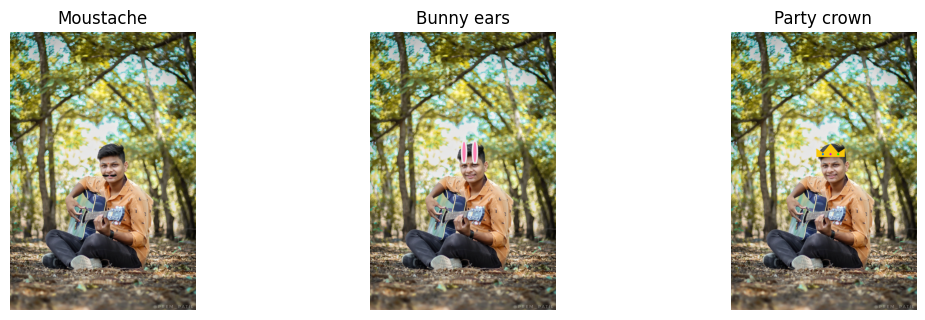

In [11]:
def make_moustache(w=180, h=70):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    black = (20, 20, 20)
    cv2.ellipse(canvas, (w // 4, h // 2), (w // 4, h // 3), 0, 0, 180, black, -1)
    cv2.ellipse(mask,   (w // 4, h // 2), (w // 4, h // 3), 0, 0, 180, 255, -1)
    cv2.ellipse(canvas, (3 * w // 4, h // 2), (w // 4, h // 3), 0, 0, 180, black, -1)
    cv2.ellipse(mask,   (3 * w // 4, h // 2), (w // 4, h // 3), 0, 0, 180, 255, -1)
    cv2.circle(canvas, (w // 2, h // 2 - 5), h // 4, (0, 0, 0), -1)
    cv2.circle(mask,   (w // 2, h // 2 - 5), h // 4, 0, -1)                 # cut a small gap in the middle
    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def make_bunny_ears(w=200, h=260):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    for cx in [w // 4, 3 * w // 4]:
        cv2.ellipse(canvas, (cx, h // 2 + 20), (30, 120), 0, 0, 360, (235, 235, 235), -1)
        cv2.ellipse(mask,   (cx, h // 2 + 20), (30, 120), 0, 0, 360, 255, -1)
        cv2.ellipse(canvas, (cx, h // 2 + 20), (14, 95), 0, 0, 360, (180, 130, 255), -1)
    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def make_crown(w=260, h=140):
    canvas = np.zeros((h, w, 3), np.uint8)
    mask = np.zeros((h, w), np.uint8)
    gold = (10, 200, 250)
    points = np.array([[10, h - 10], [10, 60], [70, 100], [w // 2, 15],
                       [w - 70, 100], [w - 10, 60], [w - 10, h - 10]])
    cv2.fillPoly(canvas, [points], gold)
    cv2.fillPoly(mask,   [points], 255)
    for cx, col in [(w // 2, (255, 0, 200)), (w // 4, (255, 120, 0)), (3 * w // 4, (0, 255, 0))]:
        cv2.circle(canvas, (cx, h - 35), 10, col, -1)
        cv2.circle(mask,   (cx, h - 35), 10, 255, -1)
    rgba = cv2.cvtColor(canvas, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask
    return rgba


def apply_moustache_filter(img, face_box):
    x, y, w, h = face_box
    m = make_moustache(int(w * 0.5), int(w * 0.5 * 70 / 180))
    return overlay_image_alpha(img.copy(), m, x + w // 2 - m.shape[1] // 2, y + int(h * 0.62))


def apply_bunny_filter(img, face_box):
    x, y, w, h = face_box
    ears = make_bunny_ears(int(w * 0.75), int(h * 0.95))
    return overlay_image_alpha(img.copy(), ears, x + w // 2 - ears.shape[1] // 2, y - int(h * 0.62))


def apply_crown_filter(img, face_box):
    x, y, w, h = face_box
    crown = make_crown(int(w * 1.05), int(h * 0.55))
    return overlay_image_alpha(img.copy(), crown, x + w // 2 - crown.shape[1] // 2, y - int(h * 0.42))


show_many([apply_moustache_filter(photo, FACE_BOX), apply_bunny_filter(photo, FACE_BOX), apply_crown_filter(photo, FACE_BOX)],
          ["Moustache", "Bunny ears", "Party crown"], cols=3)

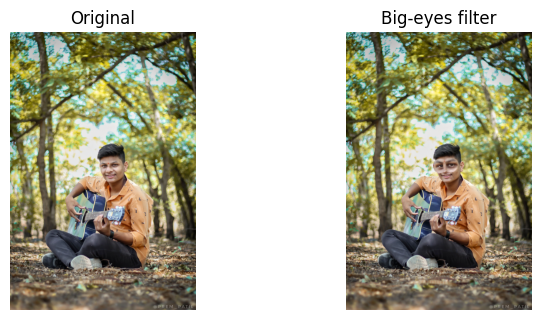

In [12]:
def apply_big_eyes(img, face_box, scale=1.6):
    out = img.copy()
    eyes = detect_eyes(img, face_box)
    if not eyes:
        print("No eyes detected -> returning the image unchanged (try a clearer / more front-facing photo)")
        return out

    for (ex, ey, ew, eh) in eyes:
        cx, cy = ex + ew // 2, ey + eh // 2
        r = int(max(ew, eh) * 0.9)                              # radius of the region we will enlarge

        y1, y2 = max(cy - r, 0), min(cy + r, out.shape[0])
        x1, x2 = max(cx - r, 0), min(cx + r, out.shape[1])
        patch = out[y1:y2, x1:x2]
        if patch.size == 0:
            continue

        big_patch = cv2.resize(patch, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
        bh, bw = big_patch.shape[:2]
        bx1, by1 = cx - bw // 2, cy - bh // 2

        # circular soft mask so the enlarged patch blends smoothly, no hard square edge
        mask = np.zeros((bh, bw), np.uint8)
        cv2.circle(mask, (bw // 2, bh // 2), int(min(bw, bh) * 0.42), 255, -1)
        mask = cv2.GaussianBlur(mask, (15, 15), 0)
        rgba_patch = cv2.cvtColor(big_patch, cv2.COLOR_BGR2BGRA)
        rgba_patch[:, :, 3] = mask
        out = overlay_image_alpha(out, rgba_patch, bx1, by1)

    return out


show_many([photo, apply_big_eyes(photo, FACE_BOX)], ["Original", "Big-eyes filter"], cols=2)

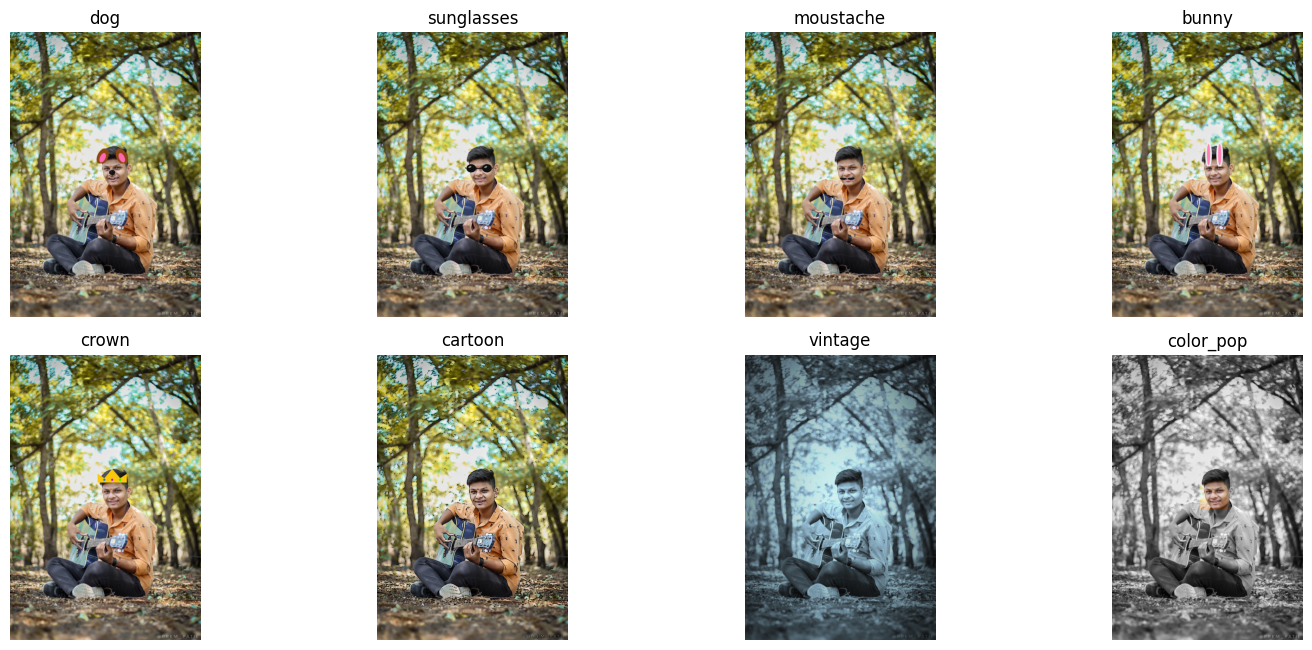

In [13]:
FILTERS = {
    "none":        lambda img, box: img,
    "grayscale":   lambda img, box: apply_grayscale(img),
    "sepia":       lambda img, box: apply_sepia(img),
    "vintage":     lambda img, box: apply_vintage(img),
    "vignette":    lambda img, box: apply_vignette(img),
    "color_pop":   lambda img, box: apply_color_pop(img, box),
    "cartoon":     lambda img, box: apply_cartoon(img),
    "beauty":      lambda img, box: apply_beauty(img, box),
    "dog":         lambda img, box: apply_dog_filter(img, box),
    "sunglasses":  lambda img, box: apply_sunglasses_filter(img, box),
    "moustache":   lambda img, box: apply_moustache_filter(img, box),
    "bunny":       lambda img, box: apply_bunny_filter(img, box),
    "crown":       lambda img, box: apply_crown_filter(img, box),
    "big_eyes":    lambda img, box: apply_big_eyes(img, box),
}


def apply_filter(img, name, face_box=None):
    """Apply one named filter. Detects the face automatically if face_box is not given."""
    if name not in FILTERS:
        raise ValueError("Unknown filter: " + name + ". Choices: " + ", ".join(FILTERS))
    if face_box is None:
        face_box = detect_face_box(img) or FACE_BOX
    return FILTERS[name](img, face_box)


names_to_show = ["dog", "sunglasses", "moustache", "bunny", "crown", "cartoon", "vintage", "color_pop"]
gallery = [apply_filter(photo, n, FACE_BOX) for n in names_to_show]
show_many(gallery, names_to_show, cols=4)

In [16]:
def live_filter_webcam(camera_index=0, mirror=True, process_every=1):
    """
    Real-time face-filter webcam app.
    Controls: 0=none 1=grayscale 2=sepia 3=vintage 4=cartoon 5=beauty
             6=dog 7=sunglasses 8=moustache 9=bunny 10 not available (use letters below)
             c = crown, b = big_eyes,  s = save snapshot,  q = quit
    """
    key_to_filter = {
        ord("0"): "none", ord("1"): "grayscale", ord("2"): "sepia", ord("3"): "vintage",
        ord("4"): "cartoon", ord("5"): "beauty", ord("6"): "dog", ord("7"): "sunglasses",
        ord("8"): "moustache", ord("9"): "bunny", ord("c"): "crown", ord("b"): "big_eyes",
    }

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("❌ Could not open the webcam (index", camera_index, "). Check it is connected and not used by another app.")
        return

    current_filter = "dog"
    last_box = None
    frame_count = 0
    prev_time = cv2.getTickCount()

    print("Live filter app started. Press a number/letter key to change filter, 's' to save, 'q' to quit.")

    while True:
        ok, frame = cap.read()
        if not ok:
            print("⚠️ Could not read a frame - stopping.")
            break

        if mirror:
            frame = cv2.flip(frame, 1)

        frame_count += 1
        if frame_count % process_every == 0 or last_box is None:
            box = detect_face_box(frame)
            if box is not None:
                last_box = box

        if last_box is not None:
            output = apply_filter(frame, current_filter, last_box)
            x, y, w, h = last_box
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        else:
            output = frame

        now = cv2.getTickCount()
        fps = cv2.getTickFrequency() / (now - prev_time)
        prev_time = now
        cv2.putText(output, "FPS: " + str(round(fps, 1)) + "  filter: " + current_filter,
                   (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        cv2.imshow("Snapchat-style filters (press q to quit)", output)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord("s"):
            filename = "snapshot_" + current_filter + ".png"
            cv2.imwrite(filename, output)
            print("Saved", filename)
        elif key in key_to_filter:
            current_filter = key_to_filter[key]
            print("Filter switched to:", current_filter)

    cap.release()
    cv2.destroyAllWindows()


# To run it locally:
live_filter_webcam()
print("Function ready. Call live_filter_webcam() in a LOCAL Python environment with a webcam and a display.")